In [2]:
import snapatac2 as snap
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
adata = snap.read_dataset(f'scATAC_QC.h5ads')

In [9]:
snap.pp.select_features(adata, n_features=100000)
snap.tl.spectral(adata)
snap.tl.umap(adata, use_rep="X_spectral",min_dist = 0.5)

2026-03-04 19:33:53 - INFO - Selected 100000 features.
/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [11]:
snap.pp.harmony(adata, batch="sample", max_iter_harmony=20)
snap.tl.umap(adata, use_rep="X_spectral_harmony")

2026-03-04 19:35:49,530 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 19:35:49 - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 19:35:50,533 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-04 19:35:50 - INFO - sklearn.KMeans initialization complete.
2026-03-04 19:35:50,602 - harmonypy - INFO - Iteration 1 of 20
2026-03-04 19:35:50 - INFO - Iteration 1 of 20
2026-03-04 19:35:53,879 - harmonypy - INFO - Iteration 2 of 20
2026-03-04 19:35:53 - INFO - Iteration 2 of 20
2026-03-04 19:35:56,777 - harmonypy - INFO - Iteration 3 of 20
2026-03-04 19:35:56 - INFO - Iteration 3 of 20
2026-03-04 19:36:00,418 - harmonypy - INFO - Iteration 4 of 20
2026-03-04 19:36:00 - INFO - Iteration 4 of 20
2026-03-04 19:36:03,883 - harmonypy - INFO - Converged after 4 iterations
2026-03-04 19:36:03 - INFO - Converged after 4 iterations
/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/umap/umap_.py:1945: UserWar

In [26]:
snap.pp.knn(adata,n_neighbors=10)
snap.tl.leiden(adata,resolution=2)

In [27]:
adata_temp = adata.to_adata()

/tmp/ipykernel_1391815/2008557010.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_1391815/2008557010.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_1391815/2008557010.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_1391815/2008557010.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



In [30]:
adata_temp.obs['leiden'].value_counts()

leiden
0     1204
1     1005
2      882
3      817
4      804
5      761
6      749
7      737
8      722
9      643
10     590
11     573
12     535
13     492
14     486
15     413
16     362
17     359
18     323
19     321
20     317
21     316
22     299
23     226
24     225
25     200
26     184
27     177
29     176
28     176
30     174
31     166
32     155
33     153
34     151
35     132
36     118
37     110
38      65
39      64
40      33
Name: count, dtype: int64

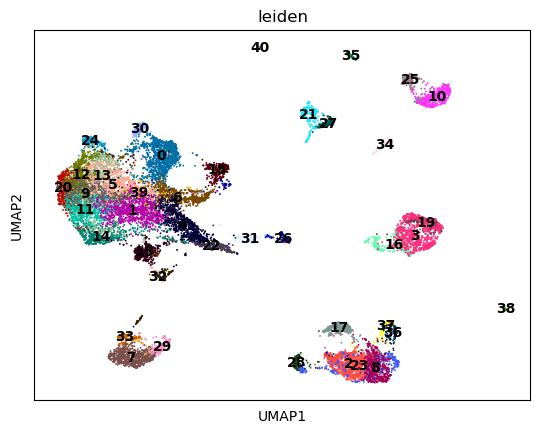

In [29]:
sc.pl.umap(adata_temp,color = 'leiden',legend_loc='on data')

In [31]:
adata_temp = adata_temp[~adata_temp.obs["leiden"].isin(['31','32','33','34','35','36','37','38','39','40'])]

In [32]:
snap.pp.select_features(adata_temp, n_features=100000)
snap.tl.spectral(adata_temp)
snap.tl.umap(adata_temp, use_rep="X_spectral")
snap.pp.knn(adata_temp,n_neighbors=10)
snap.tl.leiden(adata_temp,resolution = 0.5)

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/snapatac2/preprocessing/_basic.py:1069: ImplicitModificationWarning:

Trying to modify attribute `.var` of view, initializing view as actual.

2026-03-04 19:45:16 - INFO - Selected 100000 features.
/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



... storing 'leiden' as categorical


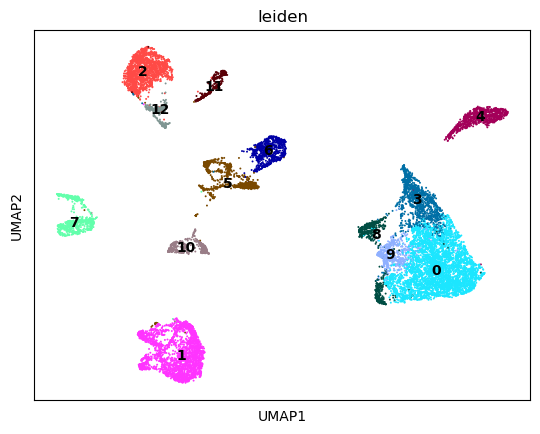

In [37]:
sc.pl.umap(adata_temp,color='leiden',legend_loc='on data')

In [ ]:
adata_sub,_ = adata.subset(obs_indices= adata_temp.obs_names,out = 'scATAC_QC') 
adata.close()

In [115]:
adata_sub = snap.read_dataset('scATAC_QC/_dataset.h5ads',backend=None)

In [60]:
adata = adata_sub.to_adata()

/tmp/ipykernel_1991453/3057649533.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_1991453/3057649533.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_1991453/3057649533.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_1991453/3057649533.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



In [61]:
snap.pp.select_features(adata, n_features=100000,max_iter=2)
snap.tl.spectral(adata)
snap.pp.harmony(adata, batch="sample", max_iter_harmony=20)
snap.tl.umap(adata, use_rep="X_spectral_harmony", min_dist=0.1)

2026-03-15 14:58:19 - INFO - Selected 100000 features.
2026-03-15 14:59:04,118 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-15 14:59:04 - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-15 14:59:04,990 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-15 14:59:04 - INFO - sklearn.KMeans initialization complete.
2026-03-15 14:59:05,049 - harmonypy - INFO - Iteration 1 of 20
2026-03-15 14:59:05 - INFO - Iteration 1 of 20
2026-03-15 14:59:07,724 - harmonypy - INFO - Iteration 2 of 20
2026-03-15 14:59:07 - INFO - Iteration 2 of 20
2026-03-15 14:59:09,706 - harmonypy - INFO - Iteration 3 of 20
2026-03-15 14:59:09 - INFO - Iteration 3 of 20
2026-03-15 14:59:10,457 - harmonypy - INFO - Iteration 4 of 20
2026-03-15 14:59:10 - INFO - Iteration 4 of 20
2026-03-15 14:59:11,199 - harmonypy - INFO - Iteration 5 of 20
2026-03-15 14:59:11 - INFO - Iteration 5 of 20
2026-03-15 14:59:11,948 - harmonypy - INFO - Converged after 5 it

In [66]:
snap.pp.knn(adata,use_rep="X_spectral_harmony",n_neighbors=10)
snap.tl.leiden(adata,resolution=0.2)

In [65]:
adata

AnnData object with n_obs × n_vars = 15248 × 606219
    obs: 'sample', 'leiden', 'cell_type'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'AnnDataSet', 'spectral_eigenvalue', 'leiden_colors'
    obsm: 'X_spectral', 'X_spectral_harmony', 'X_umap'
    obsp: 'distances'

In [67]:
adata_sub.obs['leiden'] =  adata.obs['leiden']
adata_sub.obsm["X_umap"] = adata.obsm["X_umap"]

... storing 'leiden' as categorical


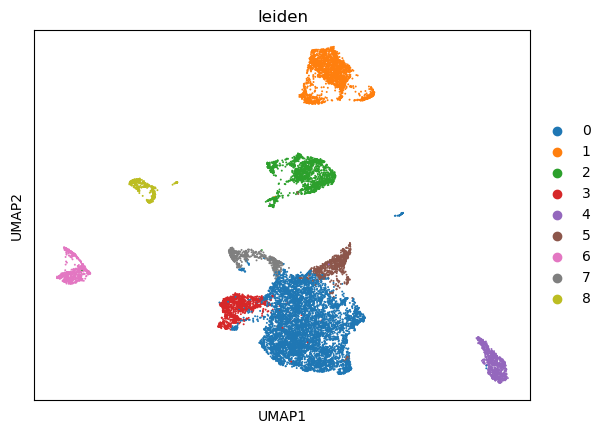

In [68]:
sc.pl.umap(adata,color = 'leiden')

In [69]:
gene_matrix = snap.pp.make_gene_matrix(adata_sub,'protein_coding_genes.gff3')

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [70]:
gene_matrix

AnnData object with n_obs × n_vars = 15248 × 19991
    obs: 'sample', 'leiden', 'cell_type'

In [72]:
all(gene_matrix.obs_names == adata.obs_names)
gene_matrix.obs['leiden'] = adata.obs['leiden'] 

In [73]:
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)

In [74]:
sc.external.pp.magic(gene_matrix, solver="approximate")
gene_matrix.obsm["X_umap"] = adata_sub.obsm["X_umap"]

... storing 'sample' as categorical
... storing 'cell_type' as categorical


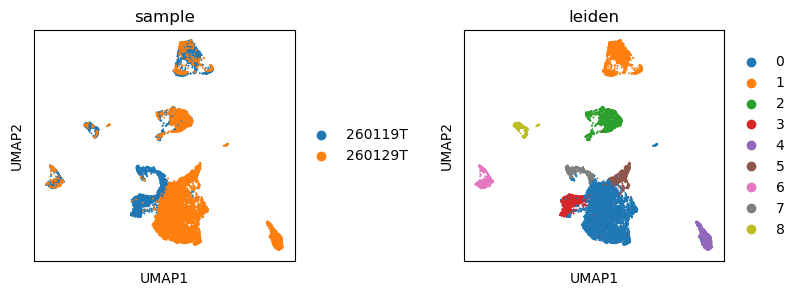

In [75]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(gene_matrix,color=['sample','leiden'],wspace=0.5)

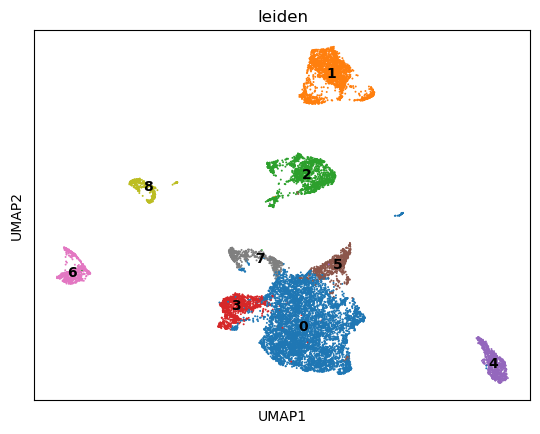

In [77]:
sc.pl.umap(gene_matrix, color=['leiden'],legend_loc='on data')

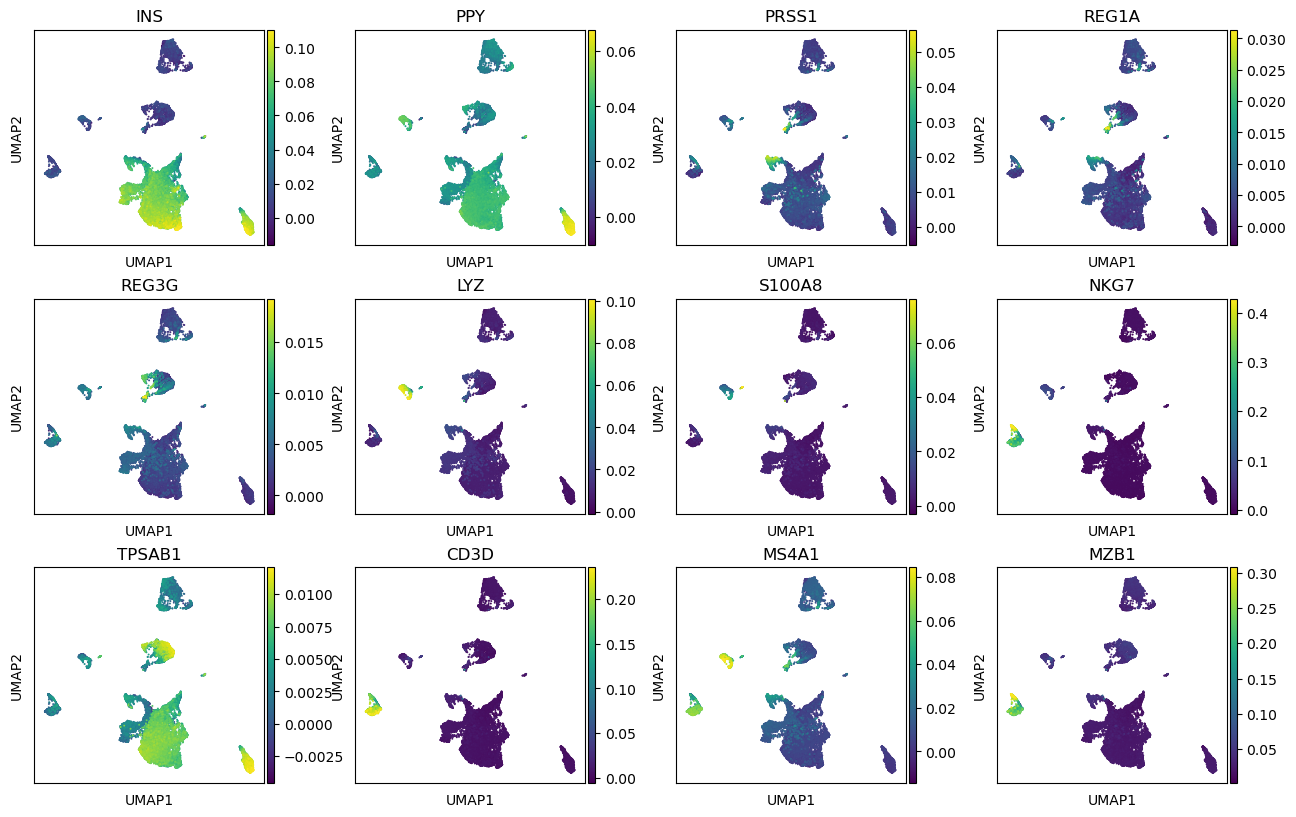

In [78]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(gene_matrix, use_raw=False, color=['INS','PPY','PRSS1',
    'REG1A','REG3G','LYZ','S100A8','NKG7','TPSAB1','CD3D','MS4A1','MZB1'])

In [79]:
adata_scRNA = sc.read_h5ad('h5ad/islet_final_annotated.h5ad')
adata_scRNA = adata_scRNA.raw.to_adata()

In [80]:
adata_scRNA.X.max()

14282.0

In [81]:
gene_matrix.var

,n_cells
OR4F5,118
SAMD11,6451
NOC2L,3894
KLHL17,2334
PLEKHN1,1649
...,...
RPS4Y2,115
RBMY1J,7
PRY,5
DAZ1,6


In [82]:
sc.tl.rank_genes_groups(gene_matrix, 'leiden',  method='t-test',use_raw=False,key_added='leiden_ttest')
leiden_top5_genes = {
    leiden: gene_matrix.uns['leiden_ttest']['names'][leiden][:20].tolist()
    for leiden in gene_matrix.uns['leiden_ttest']['names'].dtype.names
}

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning:

invalid value encountered in log2

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning:

invalid value encountered in log2

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning:

invalid value encountered in log2

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning:

invalid value encountered in log2

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning:

invalid value encountered in log2

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning:

invalid value encountered in log2

/home/armstrong/minico

In [83]:
sc.pp.normalize_total(adata_scRNA, target_sum=1e4)
sc.pp.log1p(adata_scRNA)
sc.tl.rank_genes_groups(adata_scRNA, 'cell_type',  method='t-test',use_raw=False,key_added='ct_ttest')


In [84]:
def intersect(list1,list2):
    set1 = set(list1)
    set2 = set(list2)
    intersected_set = set1.intersection(set2) 
    return(list(intersected_set))
ct_top5_genes = {
    leiden: intersect(adata_scRNA.uns['ct_ttest']['names'][leiden][:5].tolist(),gene_matrix.var_names.to_list())
    for leiden in adata_scRNA.uns['ct_ttest']['names'].dtype.names
}

In [85]:
ct_top5_genes

{'Acinar': ['GP2', 'CPB1', 'CPA1', 'CPA2', 'SPINK1'],
 'B': ['HLA-DRA', 'BANK1', 'CD83', 'RPS27', 'CD74'],
 'Beta': ['INS', 'SLC30A8', 'PCSK1N', 'SCGN', 'SCG3'],
 'Cycling cell': ['STMN1', 'TUBA1B', 'HMGN2', 'HMGB2'],
 'Endothelial': ['FLT1', 'EPAS1', 'NFIB', 'TCF4', 'PLPP1'],
 'Lymphatic Endothelial': ['TFPI', 'GNG11', 'IGFBP7', 'TFF3', 'CCL21'],
 'Macrophage': ['HLA-DRA', 'HLA-DRB1', 'HLA-DPB1', 'HLA-DPA1', 'CD74'],
 'Mast': ['CPA3', 'TPSAB1', 'SRGN', 'FTH1', 'TPSB2'],
 'Monocyte': ['S100A4', 'CTSS', 'IFI30', 'TYROBP', 'FCER1G'],
 'NK': ['GNLY', 'PTPRC', 'NKG7', 'B2M', 'CCL5'],
 'Pericyte': ['PRKG1', 'IGFBP7', 'RGS5', 'SPARCL1', 'CALD1'],
 'Stellate': ['DCN', 'IGFBP7', 'COL6A1', 'C7', 'CALD1'],
 'T': ['RPS29', 'CXCR4', 'PTPRC', 'B2M', 'RPS27']}

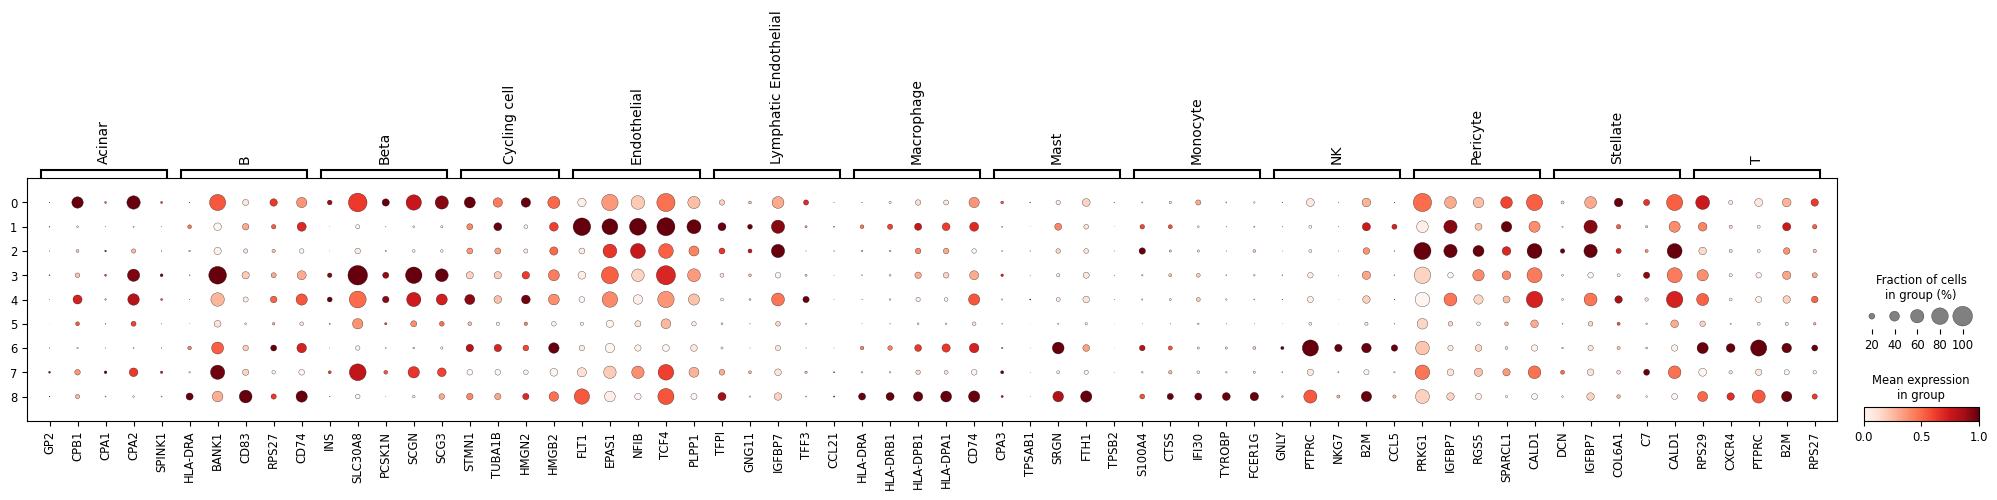

In [87]:
sc.pl.dotplot(
    gene_matrix, ct_top5_genes ,
    standard_scale='var',
    groupby='leiden')

In [88]:
leiden_ct = {
    "Beta": [0,3,5,7],
    "Endothelial": [1],
    "Pericyte": [2],
    "Myeloid": [8],
    "Lymphoid": [6],
    'Low quality' :[4]
}

In [89]:
cluster2celltype = {
    str(cluster): str(ct)
    for ct, clusters in leiden_ct.items()
    for cluster in clusters
}
adata_sub.obs['cell_type'] = [cluster2celltype[i] for i in adata_sub.obs['leiden']]
gene_matrix.obs['cell_type'] = (
    gene_matrix.obs['leiden']
    .map(cluster2celltype)
    .astype('category')
)

/tmp/ipykernel_1991453/1849270328.py:6: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



In [110]:
gene_matrix = gene_matrix[gene_matrix.obs['cell_type'] != 'Low quality']

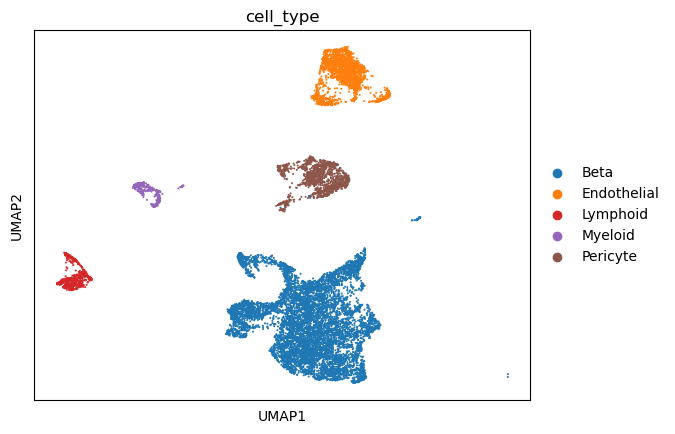

In [112]:
sc.pl.umap(gene_matrix,color = 'cell_type')

In [117]:
adata_sub

AnnDataSet object with n_obs x n_vars = 15248 x 606219 backed at 'scATAC_QC/_dataset.h5ads'
contains 2 AnnData objects with keys: '260119T', '260129T'
    obs: 'sample', 'leiden', 'cell_type'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'AnnDataSet', 'spectral_eigenvalue'
    obsm: 'X_umap', 'X_spectral', 'X_spectral_harmony'
    obsp: 'distances'

In [118]:
adata_anno,_ = adata_sub.subset(obs_indices= gene_matrix.obs_names,out = 'scATAC_raw_annotated') 
adata_sub.close()

True

In [125]:
if all(adata_anno.obs_names == gene_matrix.obs_names):
    adata_anno.obs['cell_type'] = gene_matrix.obs['cell_type']

In [126]:
adata_anno.close()

In [3]:
adata_anno = snap.read_dataset(f'scATAC_raw_annotated/_dataset.h5ads')

In [ ]:
snap.ex.export_coverage(adata_anno, groupby='cell_type',output_format = 'bigwig', out_dir='track')

In [ ]:
snap.ex.export_fragments(adata_anno,groupby='sample', suffix='.tsv.gz',out_dir = 'track')

In [128]:
snap.tl.macs3(adata_anno, groupby='cell_type',tempdir = './temp')

2026-03-15 15:43:33 - INFO - Exporting fragments...
2026-03-15 15:45:27 - INFO - Calling peaks...
100%|██████████| 5/5 [20:11<00:00, 242.24s/it]


In [129]:
merged_peaks = snap.tl.merge_peaks(adata_anno.uns['macs3'], chrom_sizes=snap.genome.hg38)
merged_peaks_df = merged_peaks.to_pandas()
merged_peaks_df.to_csv('table/scATAC_peak.csv')

/tmp/ipykernel_1991453/4127863765.py:1: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



In [130]:
peak_mat = snap.pp.make_peak_matrix(adata_anno, use_rep=merged_peaks['Peaks'])
peak_mat.write_h5ad('h5ad/scATAC_peak_annoated.h5ad',compression='gzip')
adata_anno.close()

/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.

... storing 'sample' as categorical
... storing 'leiden' as categorical


In [131]:
peak_mat

AnnData object with n_obs × n_vars = 14341 × 269441
    obs: 'sample', 'leiden', 'cell_type'

In [132]:
peak_mat = sc.read_h5ad('h5ad/scATAC_peak_annoated.h5ad')

In [133]:
snap.pp.select_features(peak_mat, n_features=100000)
snap.tl.spectral(peak_mat)
snap.pp.harmony(peak_mat, batch="sample", max_iter_harmony=20)
snap.tl.umap(peak_mat, use_rep="X_spectral_harmony")

2026-03-15 16:06:29 - INFO - Selected 100000 features.
2026-03-15 16:07:08,814 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-15 16:07:08 - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-15 16:07:09,619 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-15 16:07:09 - INFO - sklearn.KMeans initialization complete.
2026-03-15 16:07:09,671 - harmonypy - INFO - Iteration 1 of 20
2026-03-15 16:07:09 - INFO - Iteration 1 of 20
2026-03-15 16:07:12,159 - harmonypy - INFO - Iteration 2 of 20
2026-03-15 16:07:12 - INFO - Iteration 2 of 20
2026-03-15 16:07:13,915 - harmonypy - INFO - Iteration 3 of 20
2026-03-15 16:07:13 - INFO - Iteration 3 of 20
2026-03-15 16:07:14,610 - harmonypy - INFO - Converged after 3 iterations
2026-03-15 16:07:14 - INFO - Converged after 3 iterations
/home/armstrong/miniconda3/envs/omicverse/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random

In [135]:
peak_mat.write_h5ad('h5ad/scATAC_peak_final_annoated.h5ad',compression='gzip')

In [136]:
peak_mat = sc.read_h5ad('h5ad/scATAC_peak_final_annoated.h5ad')

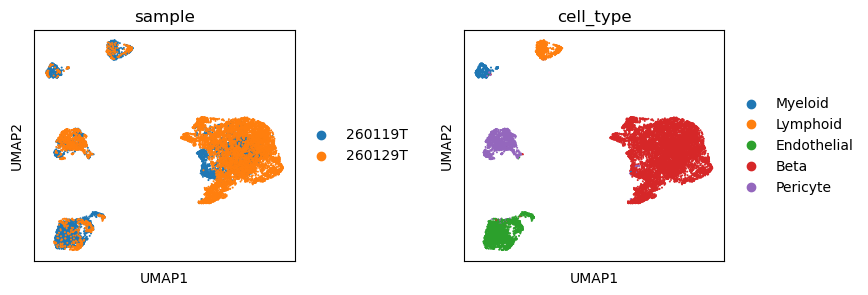

In [138]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(peak_mat,color=['sample','cell_type'],wspace=0.5)

In [144]:
peak_mat.obs['cell_type'].cat.categories

Index(['Myeloid', 'Lymphoid', 'Endothelial', 'Beta', 'Pericyte'], dtype='object')

In [139]:
peak_mat.obs.to_csv('table/scATAC_PanNET_obs.csv')